# Notebook 1: Simulator & Baseline Development

**Goal:** Verify the core simulator physics and the baseline controller logic function correctly for both Oslo and Riyadh scenarios before involving ML.

## 1. Setup and Imports

Import necessary libraries and custom modules. Ensure the paths are correct relative to the `notebooks/` directory.

In [1]:
import sys
import os
import yaml
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random

# --- Add project root to sys.path ---
# This allows importing modules from sibling directories (simulator, controllers)
notebook_dir = os.getcwd() # Should be AGARTECHdiss_simplified/notebooks
project_root = os.path.abspath(os.path.join(notebook_dir, '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)
    print(f"Added '{project_root}' to sys.path")

# --- Import project modules ---
try:
    from simulator.core import GreenhouseSimulator, SensorSnapshot, ControlState, vapor_pressure_deficit
    from controllers.baseline import BaselineController
    print("Successfully imported project modules.")
except ImportError as e:
    print(f"ERROR: Failed to import project modules: {e}")
    print("Ensure you are running this notebook from the 'notebooks' directory")
    print("and that __init__.py files exist in sibling directories.")

# --- Plotting Style ---
sns.set_theme(style="ticks", context="notebook")
plt.rcParams['figure.figsize'] = (12, 6)

Successfully imported project modules.


## 2. Load City Configurations

Load the YAML configuration files for Oslo and Riyadh.

In [2]:
city_config_dir = os.path.join(project_root, 'simulator', 'city_configs')
oslo_config_path = os.path.join(city_config_dir, 'oslo.yaml')
riyadh_config_path = os.path.join(city_config_dir, 'riyadh.yaml')

try:
    with open(oslo_config_path, 'r') as f:
        oslo_config = yaml.safe_load(f)
    with open(riyadh_config_path, 'r') as f:
        riyadh_config = yaml.safe_load(f)
    print("City configurations loaded successfully.")
    # print("\nOslo Config:", oslo_config)
    # print("\nRiyadh Config:", riyadh_config)
except FileNotFoundError as e:
    print(f"ERROR: Config file not found: {e}")
except Exception as e:
    print(f"ERROR loading config files: {e}")

# Extract default targets for later use
TARGETS_OSLO = {k.replace('default_target_',''): v for k, v in oslo_config.items() if k.startswith('default_target_')}
TARGETS_RIYADH = {k.replace('default_target_',''): v for k, v in riyadh_config.items() if k.startswith('default_target_')}

City configurations loaded successfully.


## 3. Test Simulator Initialization and Step

Instantiate the simulator for each city and run a few steps with fixed controls to observe basic state changes.

In [3]:
# --- Test Oslo Simulator ---
print("--- Testing Oslo Simulator ---")
try:
    sim_oslo = GreenhouseSimulator(city_config_path=oslo_config_path, sim_month=7) # Simulate July
    print(f"Initial State (Oslo): T={sim_oslo.temp_c:.1f}C, RH={sim_oslo.rh:.1f}%, SM={sim_oslo.sm:.1f}%, Tank={sim_oslo.rain_tank:.0f}L")

    # Example: Run with AC ON for a few steps
    controls_ac_on = ControlState(ac=True)
    print("\nRunning 3 steps with AC ON...")
    for i in range(3):
        snapshot = sim_oslo.step(dt_min=5, controls=controls_ac_on, target_temp_midpoint=18.0)
        print(f" Step {i+1}: T={snapshot.t_c:.2f}, RH={snapshot.rh:.2f}, SM={snapshot.sm:.2f}, VPD={snapshot.vpd:.3f}, Tank={snapshot.rain_tank_l:.1f}")

except Exception as e:
    print(f"ERROR testing Oslo simulator: {e}")

# --- Test Riyadh Simulator ---
print("\n--- Testing Riyadh Simulator ---")
try:
    sim_riyadh = GreenhouseSimulator(city_config_path=riyadh_config_path, sim_month=7) # Simulate July
    print(f"Initial State (Riyadh): T={sim_riyadh.temp_c:.1f}C, RH={sim_riyadh.rh:.1f}%, SM={sim_riyadh.sm:.1f}%, Tank={sim_riyadh.rain_tank:.0f}L")

    # Example: Run with Irrigation ON for a few steps
    controls_irr_on = ControlState(irrigation=True)
    print("\nRunning 3 steps with Irrigation ON...")
    for i in range(3):
        snapshot = sim_riyadh.step(dt_min=5, controls=controls_irr_on, target_temp_midpoint=25.0)
        print(f" Step {i+1}: T={snapshot.t_c:.2f}, RH={snapshot.rh:.2f}, SM={snapshot.sm:.2f}, VPD={snapshot.vpd:.3f}, Tank={snapshot.rain_tank_l:.1f}")

except Exception as e:
    print(f"ERROR testing Riyadh simulator: {e}")

--- Testing Oslo Simulator ---
Initial State (Oslo): T=18.0C, RH=70.0%, SM=55.0%, Tank=400L

Running 3 steps with AC ON...
 Step 1: T=19.59, RH=70.70, SM=54.12, VPD=0.666, Tank=402.1
 Step 2: T=16.33, RH=71.20, SM=53.27, VPD=0.534, Tank=404.2
 Step 3: T=18.01, RH=71.90, SM=52.44, VPD=0.579, Tank=406.2

--- Testing Riyadh Simulator ---
Initial State (Riyadh): T=25.0C, RH=45.0%, SM=40.0%, Tank=50L

Running 3 steps with Irrigation ON...
 Step 1: T=25.12, RH=46.45, SM=39.92, VPD=1.706, Tank=49.0
 Step 2: T=25.25, RH=47.90, SM=39.85, VPD=1.672, Tank=48.0
 Step 3: T=25.37, RH=49.35, SM=39.77, VPD=1.637, Tank=47.0


## 4. Test Baseline Controller Logic

Instantiate the baseline controller for different modes and cities. Provide sample sensor states and check the controller's output actions.

In [4]:
# --- Test Oslo Baseline ---
print("\n--- Testing Oslo Baseline Controller ---")
try:
    # Normal Mode - Example: Cool day, low humidity, dry soil
    bl_oslo_normal = BaselineController(city_config=oslo_config, target_ranges=TARGETS_OSLO, eco_mode=False)
    state1 = SensorSnapshot(t_c=17.0, rh=60.0, sm=45.0, vpd=0.0, rain_tank_l=300)
    controls1 = bl_oslo_normal.get_controls(state1, outside_temp=15.0, outside_rh=70.0, is_raining=False)
    print(f"Oslo Normal (Cool/Dry): State={state1.t_c:.1f}C, {state1.rh:.0f}%, {state1.sm:.0f}% -> Controls={controls1}")

    # Normal Mode - Example: Hot day, high humidity, wet soil
    state2 = SensorSnapshot(t_c=22.0, rh=80.0, sm=70.0, vpd=0.0, rain_tank_l=300)
    controls2 = bl_oslo_normal.get_controls(state2, outside_temp=18.0, outside_rh=70.0, is_raining=False)
    print(f"Oslo Normal (Hot/Humid): State={state2.t_c:.1f}C, {state2.rh:.0f}%, {state2.sm:.0f}% -> Controls={controls2}")

    # Eco Mode - Example: Hot day, high humidity, wet soil
    bl_oslo_eco = BaselineController(city_config=oslo_config, target_ranges=TARGETS_OSLO, eco_mode=True)
    controls3 = bl_oslo_eco.get_controls(state2, outside_temp=18.0, outside_rh=70.0, is_raining=False)
    print(f"Oslo Eco (Hot/Humid):   State={state2.t_c:.1f}C, {state2.rh:.0f}%, {state2.sm:.0f}% -> Controls={controls3}")

except Exception as e:
    print(f"ERROR testing Oslo baseline: {e}")

# --- Test Riyadh Baseline ---
print("\n--- Testing Riyadh Baseline Controller ---")
try:
    # Normal Mode - Example: Hot day, low humidity, dry soil
    bl_riyadh_normal = BaselineController(city_config=riyadh_config, target_ranges=TARGETS_RIYADH, eco_mode=False)
    state3 = SensorSnapshot(t_c=30.0, rh=35.0, sm=30.0, vpd=0.0, rain_tank_l=50)
    controls4 = bl_riyadh_normal.get_controls(state3, outside_temp=35.0, outside_rh=25.0, is_raining=False)
    print(f"Riyadh Normal (Hot/Dry): State={state3.t_c:.1f}C, {state3.rh:.0f}%, {state3.sm:.0f}% -> Controls={controls4}")

    # Eco Mode - Example: Hot day, low humidity, dry soil
    bl_riyadh_eco = BaselineController(city_config=riyadh_config, target_ranges=TARGETS_RIYADH, eco_mode=True)
    controls5 = bl_riyadh_eco.get_controls(state3, outside_temp=35.0, outside_rh=25.0, is_raining=False)
    print(f"Riyadh Eco (Hot/Dry):   State={state3.t_c:.1f}C, {state3.rh:.0f}%, {state3.sm:.0f}% -> Controls={controls5}")

except Exception as e:
    print(f"ERROR testing Riyadh baseline: {e}")


--- Testing Oslo Baseline Controller ---
Oslo Normal (Cool/Dry): State=17.0C, 60%, 45% -> Controls=ControlState(fan=False, ac=False, vent=False, irrigation=True)
Oslo Normal (Hot/Humid): State=22.0C, 80%, 70% -> Controls=ControlState(fan=True, ac=True, vent=True, irrigation=False)
Oslo Eco (Hot/Humid):   State=22.0C, 80%, 70% -> Controls=ControlState(fan=False, ac=True, vent=True, irrigation=False)

--- Testing Riyadh Baseline Controller ---
Riyadh Normal (Hot/Dry): State=30.0C, 35%, 30% -> Controls=ControlState(fan=True, ac=True, vent=False, irrigation=True)
Riyadh Eco (Hot/Dry):   State=30.0C, 35%, 30% -> Controls=ControlState(fan=False, ac=True, vent=False, irrigation=True)


## 5. Baseline Simulation Run (Example: Oslo Normal)

Run a short simulation (e.g., 1 day = 288 steps) using the baseline controller to visualize its behavior.


--- Running 1-Day Baseline Simulation (Oslo Normal) ---
Simulation complete. Log shape: (288, 13)
Plotting results...


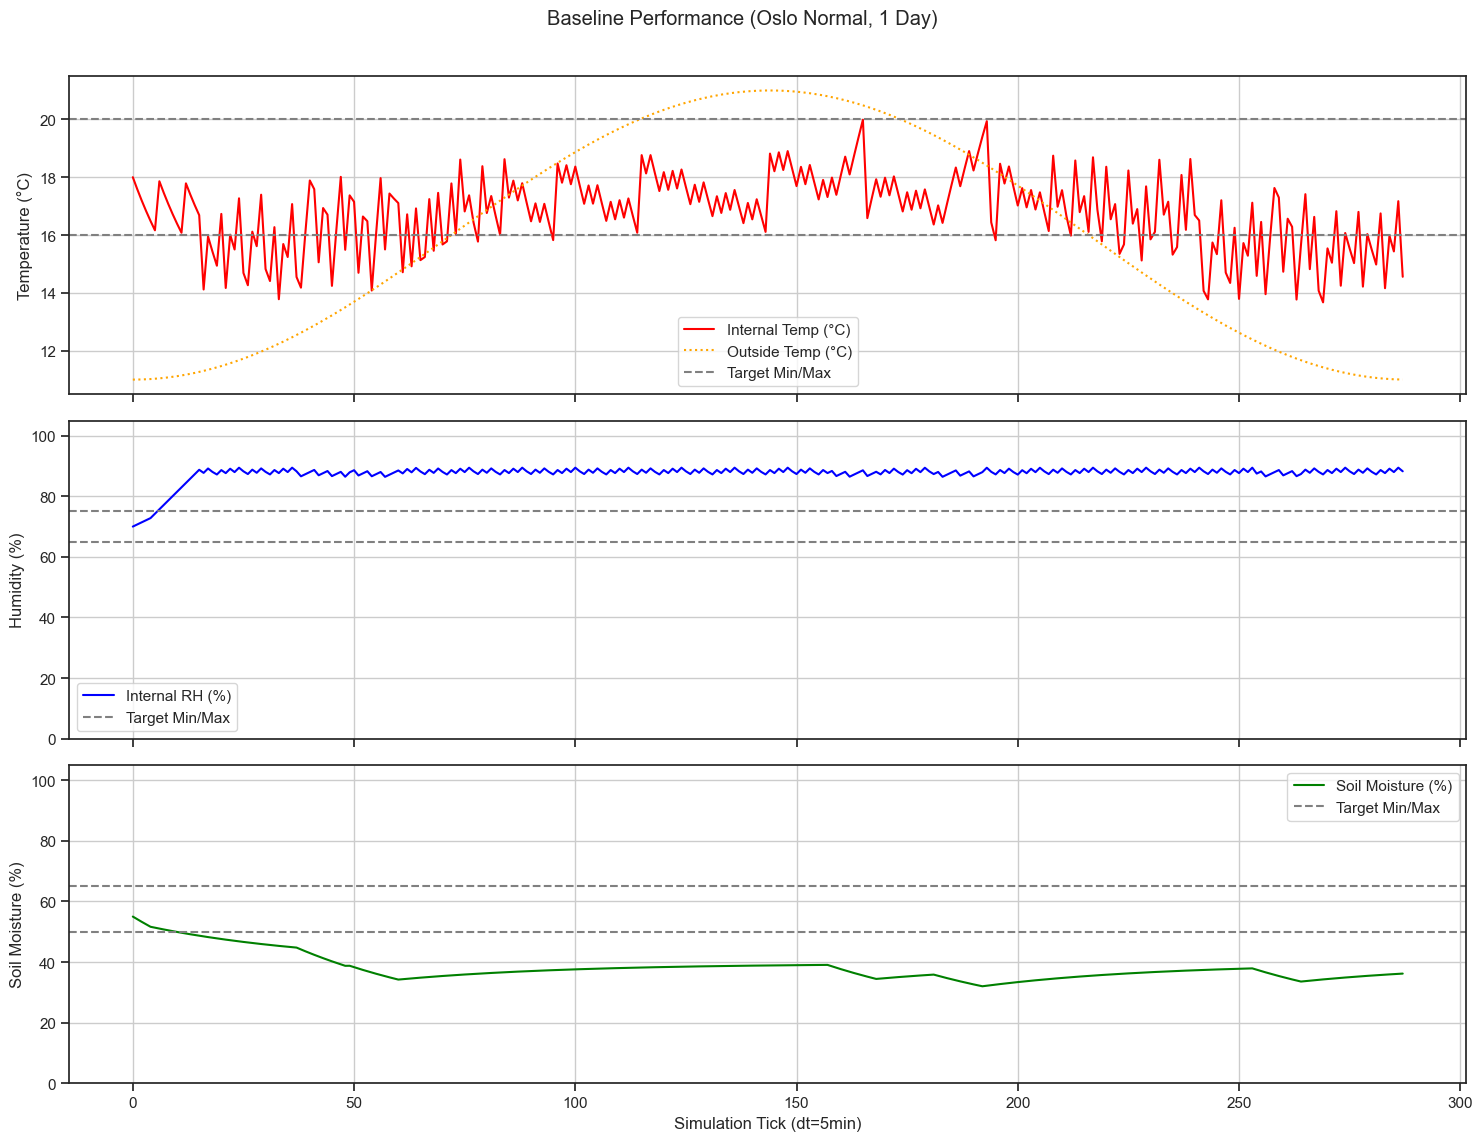

In [5]:
print("\n--- Running 1-Day Baseline Simulation (Oslo Normal) ---")

sim_run_log = []
try:
    # Initialize simulator and controller
    sim = GreenhouseSimulator(city_config_path=oslo_config_path, sim_month=7)
    controller = BaselineController(city_config=oslo_config, target_ranges=TARGETS_OSLO, eco_mode=False)
    snapshot = SensorSnapshot(sim.temp_c, sim.rh, sim.sm, vapor_pressure_deficit(sim.temp_c, sim.rh), sim.rain_tank)
    target_midpoint = (TARGETS_OSLO['t_c_min'] + TARGETS_OSLO['t_c_max']) / 2.0

    num_steps = 288 # 1 day at dt=5min

    for step in range(num_steps):
        # Get state info for controller
        outside_temp = sim.get_outside_temp()
        outside_rh = sim.outside_rh
        is_raining = sim._is_scheduled_raining() or sim.is_rainstorm_active()

        # Get controls
        controls = controller.get_controls(snapshot, outside_temp, outside_rh, is_raining)

        # Log state *before* stepping
        log_entry = snapshot.to_dict()
        log_entry['tick'] = step
        log_entry['outside_temp'] = outside_temp
        log_entry['fan'] = int(controls.fan)
        log_entry['ac'] = int(controls.ac)
        log_entry['vent'] = int(controls.vent)
        log_entry['irrigation'] = int(controls.irrigation)
        log_entry['kwh'] = sim.resource_totals()['kwh']
        log_entry['water_l'] = sim.resource_totals()['water_l']
        sim_run_log.append(log_entry)

        # Step simulator
        snapshot = sim.step(dt_min=5, controls=controls, target_temp_midpoint=target_midpoint)

    sim_df = pd.DataFrame(sim_run_log)
    print(f"Simulation complete. Log shape: {sim_df.shape}")

    # --- Plotting Results ---
    print("Plotting results...")
    fig, axes = plt.subplots(3, 1, figsize=(15, 12), sharex=True)
    fig.suptitle("Baseline Performance (Oslo Normal, 1 Day)")

    # Temperature
    axes[0].plot(sim_df['tick'], sim_df['t_c'], label='Internal Temp (°C)', color='red')
    axes[0].plot(sim_df['tick'], sim_df['outside_temp'], label='Outside Temp (°C)', color='orange', linestyle=':')
    axes[0].axhline(TARGETS_OSLO['t_c_min'], color='gray', linestyle='--', label='Target Min/Max')
    axes[0].axhline(TARGETS_OSLO['t_c_max'], color='gray', linestyle='--')
    axes[0].set_ylabel("Temperature (°C)")
    axes[0].legend()
    axes[0].grid(True)

    # Humidity
    axes[1].plot(sim_df['tick'], sim_df['rh'], label='Internal RH (%)', color='blue')
    axes[1].axhline(TARGETS_OSLO['rh_min'], color='gray', linestyle='--', label='Target Min/Max')
    axes[1].axhline(TARGETS_OSLO['rh_max'], color='gray', linestyle='--')
    axes[1].set_ylabel("Humidity (%)")
    axes[1].set_ylim(0, 105)
    axes[1].legend()
    axes[1].grid(True)

    # Soil Moisture
    axes[2].plot(sim_df['tick'], sim_df['sm'], label='Soil Moisture (%)', color='green')
    axes[2].axhline(TARGETS_OSLO['sm_min'], color='gray', linestyle='--', label='Target Min/Max')
    axes[2].axhline(TARGETS_OSLO['sm_max'], color='gray', linestyle='--')
    axes[2].set_ylabel("Soil Moisture (%)")
    axes[2].set_xlabel("Simulation Tick (dt=5min)")
    axes[2].set_ylim(0, 105)
    axes[2].legend()
    axes[2].grid(True)

    plt.tight_layout(rect=[0, 0.03, 1, 0.97]) # Adjust layout
    plt.show()

except Exception as e:
    print(f"ERROR during baseline simulation run: {e}")
    import traceback
    traceback.print_exc()


## 6. Conclusion

This notebook verified the basic functionality of the `GreenhouseSimulator` for both Oslo and Riyadh configurations and tested the output logic of the `BaselineController` in Normal and Eco modes. A short baseline simulation run provided a visual check of the system dynamics. The core components appear ready for integration into the ML environment wrapper.

In [6]:
# --- Notebook 01 Diagnostics Cell ---
import pandas as pd # Ensure pandas is imported if not already
from datetime import datetime

print("--- Notebook 01 Diagnostics ---")
print(f"Timestamp: {datetime.now()}")

# Check if simulator objects were created
sim_oslo_created = 'sim_oslo' in locals() and sim_oslo is not None
sim_riyadh_created = 'sim_riyadh' in locals() and sim_riyadh is not None
print(f"\nSimulator Instantiation:")
print(f"- Oslo Simulator Created: {sim_oslo_created}")
print(f"- Riyadh Simulator Created: {sim_riyadh_created}")

# Check if baseline controllers were created
bl_oslo_n_created = 'bl_oslo_normal' in locals() and bl_oslo_normal is not None
bl_oslo_e_created = 'bl_oslo_eco' in locals() and bl_oslo_eco is not None
bl_riyadh_n_created = 'bl_riyadh_normal' in locals() and bl_riyadh_normal is not None
bl_riyadh_e_created = 'bl_riyadh_eco' in locals() and bl_riyadh_eco is not None
print(f"\nBaseline Controller Instantiation:")
print(f"- Oslo Normal Baseline Created: {bl_oslo_n_created}")
print(f"- Oslo Eco Baseline Created: {bl_oslo_e_created}")
print(f"- Riyadh Normal Baseline Created: {bl_riyadh_n_created}")
print(f"- Riyadh Eco Baseline Created: {bl_riyadh_e_created}")


# Check results of the 1-day simulation run (if it ran and created sim_df)
print(f"\n1-Day Baseline Simulation Run (Oslo Normal Example):")
if 'sim_df' in locals() and isinstance(sim_df, pd.DataFrame) and not sim_df.empty:
    print(f"- Simulation Ran: Yes")
    print(f"- Log Shape: {sim_df.shape}")
    try:
        final_row = sim_df.iloc[-1]
        print(f"- Final State (Tick {int(final_row.get('tick', -1))}):") # Use .get for safety
        print(f"  - Temp: {final_row.get('t_c', float('nan')):.2f}°C")
        print(f"  - RH: {final_row.get('rh', float('nan')):.2f}%")
        print(f"  - SM: {final_row.get('sm', float('nan')):.2f}%")
        print(f"- Final Resources:")
        print(f"  - Energy: {final_row.get('kwh', float('nan')):.3f} kWh")
        print(f"  - Water: {final_row.get('water_l', float('nan')):.3f} L")
    except Exception as e:
        print(f"- Error processing simulation results: {e}")
else:
    print("- Simulation Ran: No or Failed/Variable 'sim_df' not found.")

print("\n--- End Notebook 01 Diagnostics ---")

--- Notebook 01 Diagnostics ---
Timestamp: 2025-05-06 20:04:44.315871

Simulator Instantiation:
- Oslo Simulator Created: True
- Riyadh Simulator Created: True

Baseline Controller Instantiation:
- Oslo Normal Baseline Created: True
- Oslo Eco Baseline Created: True
- Riyadh Normal Baseline Created: True
- Riyadh Eco Baseline Created: True

1-Day Baseline Simulation Run (Oslo Normal Example):
- Simulation Ran: Yes
- Log Shape: (288, 13)
- Final State (Tick 287):
  - Temp: 14.56°C
  - RH: 88.25%
  - SM: 36.17%
- Final Resources:
  - Energy: 4.347 kWh
  - Water: 228.000 L

--- End Notebook 01 Diagnostics ---
